# NAP AD report figures

This notebook regenerates the Napoli defensive-transition figures from the local StatsBomb match set. The league baseline is computed from the same Napoli match sample, using the other teams in those matches as the comparison group.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import statsbomb_helper as sb

team_name = "Napoli"
figure_dir = Path("figures/nap_ad")
figure_dir.mkdir(parents=True, exist_ok=True)

matches = sb.load_matches()
team_matches = sb.team_matches(team_name, matches)
team_matches[["date", "home", "away", "score", "statsbomb"]]


,date,home,away,score,statsbomb
15,2025-09-18,Manchester City,Napoli,2-0,4028848
34,2025-10-01,Napoli,Sporting CP,2-1,4028897
42,2025-10-21,PSV,Napoli,6-2,4028900
54,2025-11-04,Napoli,Frankfurt,0-0,4028923
79,2025-11-25,Napoli,Qarabag,2-0,4028820
102,2025-12-10,Benfica,Napoli,2-0,4028951
111,2026-01-20,København,Napoli,1-1,4028957
139,2026-01-28,Napoli,Chelsea,2-3,4028970


## Load events

The analysis uses the matches currently present in `data/statsbomb/league_phase/`. Re-run this notebook after refreshing the Polybox data and rebuilding `matches.csv`.

In [2]:
match_ids = team_matches["statsbomb"].tolist()
events = sb.load_team_events(team_name, match_ids)
events = sb.orient_events_for_team(events, team_name, matches, flip_away=False)

all_events = sb.load_matches_events(match_ids)
all_events = sb.orient_events_for_team(all_events, team_name, matches, flip_away=False)

print(f"{team_name} matches: {len(match_ids)}")
print(f"Events in comparison sample: {len(all_events):,}")


Napoli matches: 8
Events in comparison sample: 29,726


## Headline league benchmarking

Use these one-line comparisons in the report sections so every headline claim has the league baseline beside it.

In [3]:
benchmark = sb.headline_metric_comparison(
    all_events,
    team_name,
    loss_window_seconds=30,
    recovery_max_seconds=60,
)
benchmark


,metric,Napoli,league_average,comparison
0,Pressures,154.750000,190.500000,Napoli pressures = 154.75 vs league 190.50.
1,Recoveries,41.750000,40.750000,Napoli recoveries = 41.75 vs league 40.75.
2,Interceptions,4.500000,7.125000,Napoli interceptions = 4.50 vs league 7.12.
3,Ball losses,106.250000,102.500000,Napoli ball losses = 106.25 vs league 102.50.
4,Loss-to-shot rate,0.064706,0.038236,Napoli loss-to-shot rate = 0.06 vs league 0.04.
5,Recovery time,7.978648,7.519154,Napoli recovery time = 7.98 vs league 7.52.


In [4]:
for line in benchmark["comparison"]:
    print(line)


Napoli pressures = 154.75 vs league 190.50.
Napoli recoveries = 41.75 vs league 40.75.
Napoli interceptions = 4.50 vs league 7.12.
Napoli ball losses = 106.25 vs league 102.50.
Napoli loss-to-shot rate = 0.06 vs league 0.04.
Napoli recovery time = 7.98 vs league 7.52.


## Figure 1: Napoli ball losses

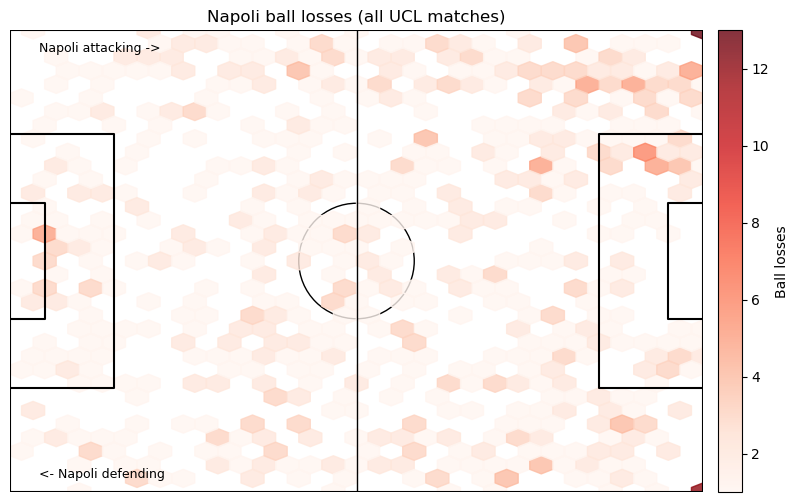

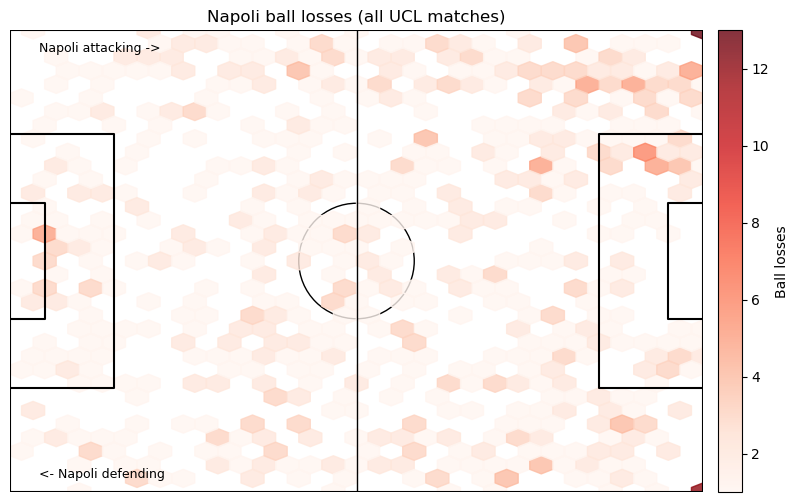

In [5]:
fig_ball_losses, ax_ball_losses = sb.plot_ball_loss_heatmap(
    events,
    team_name,
    title=f"{team_name} ball losses (all UCL matches)",
)
fig_ball_losses.savefig(figure_dir / "napoli_ball_losses.png", dpi=200, bbox_inches="tight")
fig_ball_losses


## Figure 2: Napoli defensive actions

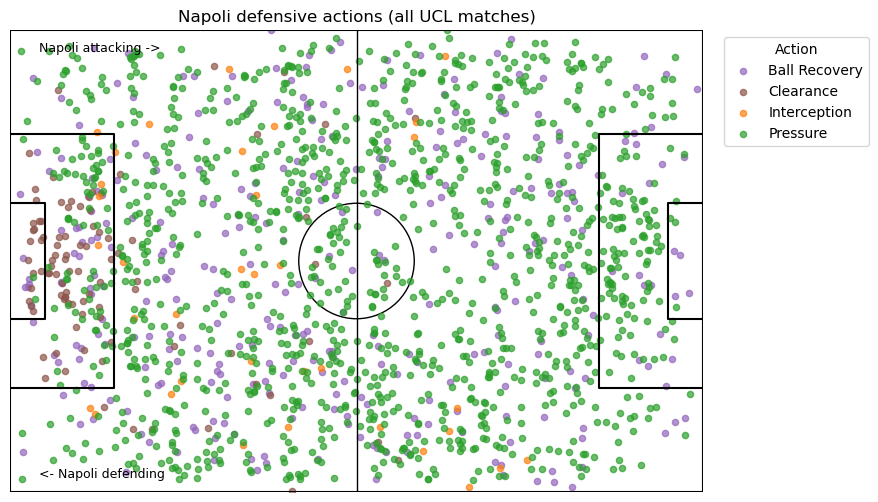

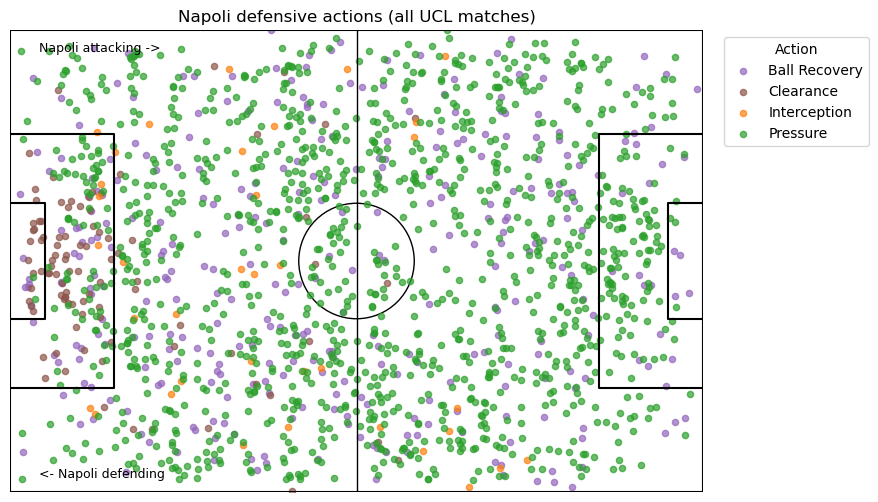

In [6]:
fig_def_actions, ax_def_actions = sb.plot_defensive_action_map(
    events,
    team_name,
    title=f"{team_name} defensive actions (all UCL matches)",
)
fig_def_actions.savefig(figure_dir / "napoli_defensive_actions.png", dpi=200, bbox_inches="tight")
fig_def_actions


## Figure 3: Napoli interception density

This replaces the previous interception hexbin with a smoothed defensive-action density plot.

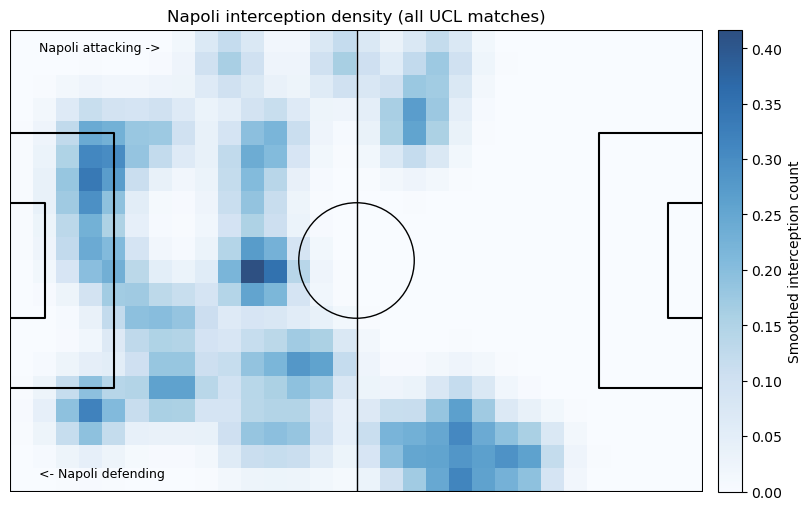

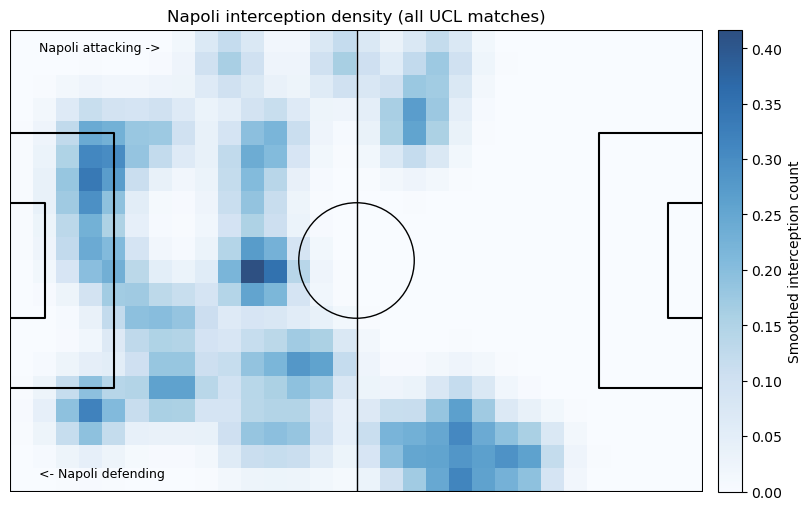

In [7]:
fig_interceptions, ax_interceptions = sb.plot_defensive_action_density(
    events,
    team_name,
    action_type="Interception",
    title=f"{team_name} interception density (all UCL matches)",
)
fig_interceptions.savefig(figure_dir / "napoli_interception_density.png", dpi=200, bbox_inches="tight")
fig_interceptions


## Figure 4: Napoli ball-loss danger vs league average

Primary loss-danger figure: positive values mark zones where Napoli losses become opponent shots more often than the league baseline in the same match sample.

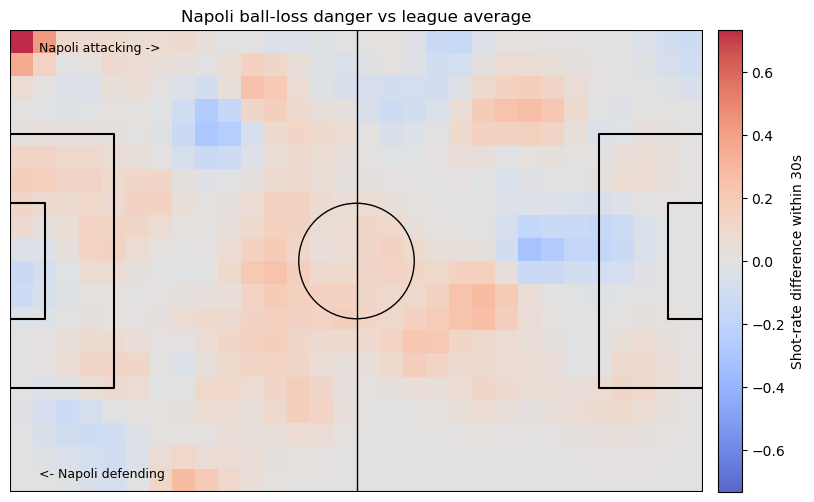

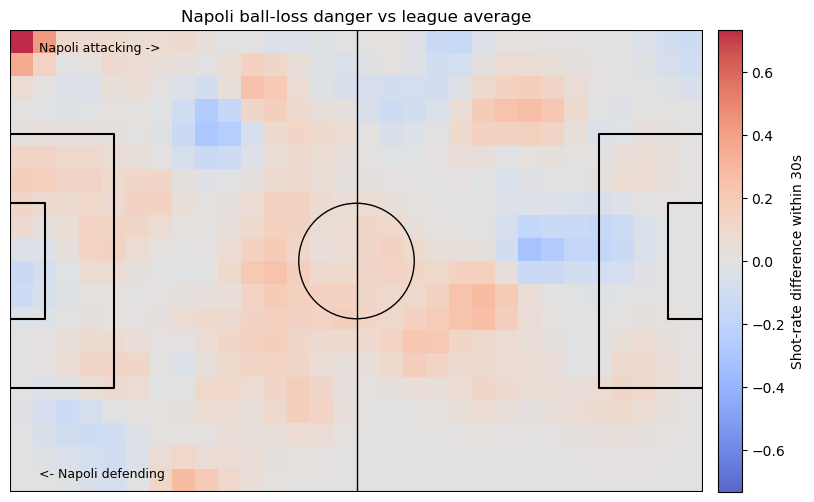

In [ ]:
fig_loss_vs_avg, ax_loss_vs_avg = sb.plot_loss_to_shot_rate_vs_average(
    all_events,
    team_name,
    window_seconds=30,
    title=f"{team_name} ball-loss danger vs league average (corners excluded)",
    exclude_corners=True,
)
fig_loss_vs_avg.savefig(figure_dir / "napoli_loss_to_shot_rate_vs_average.png", dpi=200, bbox_inches="tight")
fig_loss_vs_avg


## Figure 5: Napoli absolute loss-to-shot rate

Secondary figure for a wiki drop-down: absolute share of Napoli ball losses followed by an opponent shot within 30 seconds.

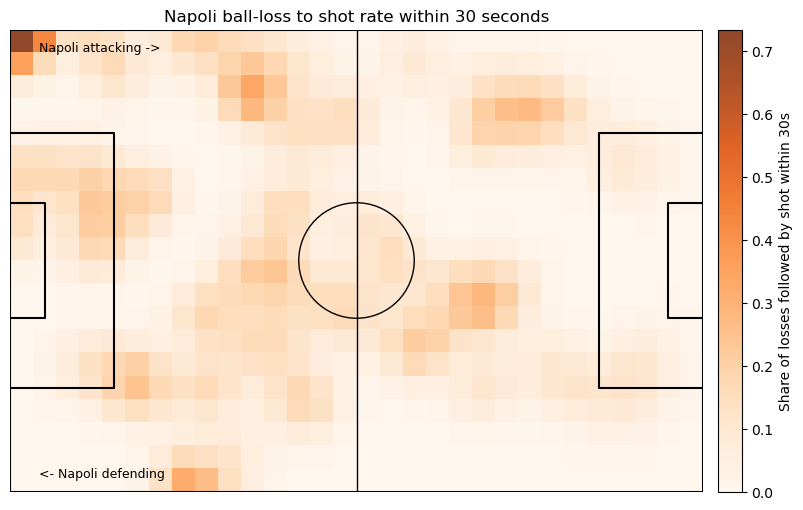

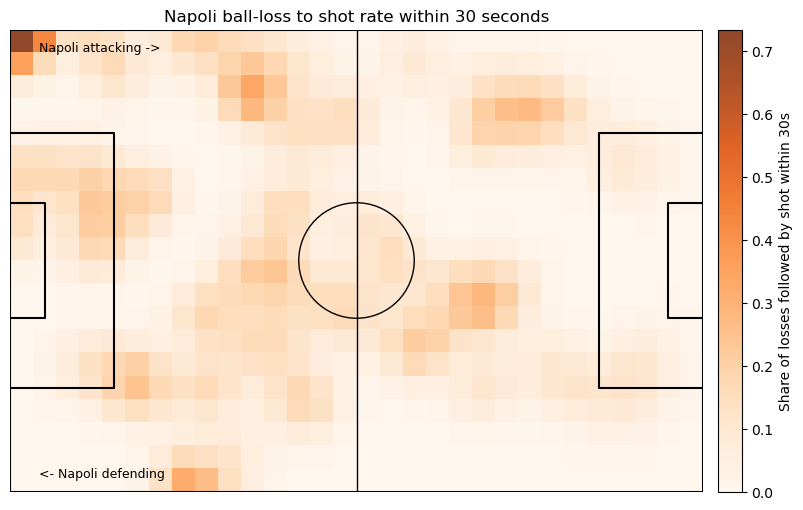

In [9]:
fig_loss_rate, ax_loss_rate = sb.plot_loss_to_shot_rate(
    all_events,
    team_name,
    window_seconds=30,
    title=f"{team_name} ball-loss to shot rate within 30 seconds",
)
fig_loss_rate.savefig(figure_dir / "napoli_loss_to_shot_rate.png", dpi=200, bbox_inches="tight")
fig_loss_rate


## Optional context figures

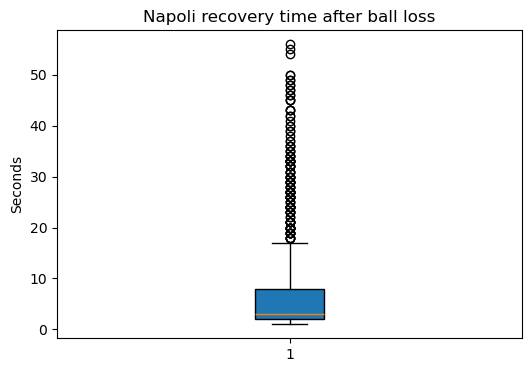

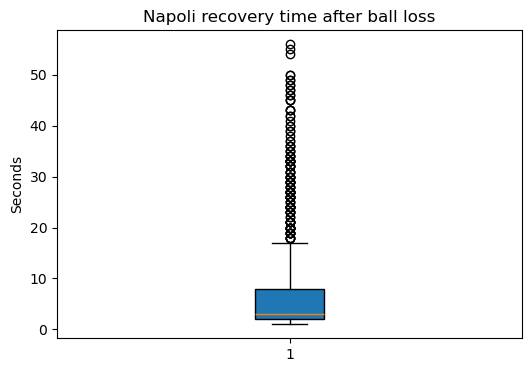

In [10]:
fig_recovery, ax_recovery = sb.plot_recovery_time_boxplot(
    all_events,
    team_name,
    max_seconds=60,
    title=f"{team_name} recovery time after ball loss",
)
fig_recovery.savefig(figure_dir / "napoli_recovery_time.png", dpi=200, bbox_inches="tight")
fig_recovery


## Optional context: recovery time without worst 10%

This companion box plot removes the slowest 10% of recovery observations to show the typical range without the longest tail.

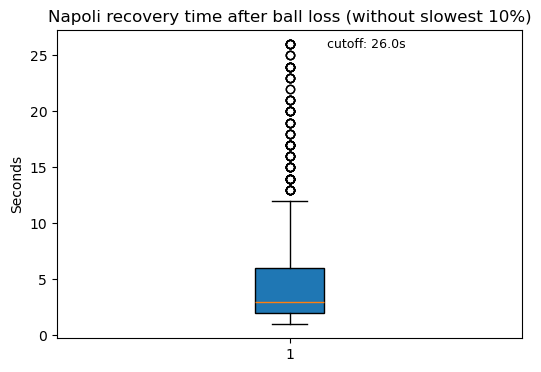

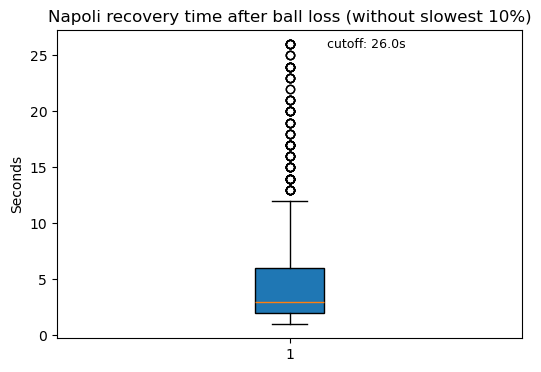

In [11]:
fig_recovery_trimmed, ax_recovery_trimmed = sb.plot_recovery_time_boxplot_without_worst(
    all_events,
    team_name,
    max_seconds=60,
    worst_share=0.10,
    title=f"{team_name} recovery time after ball loss (without slowest 10%)",
)
fig_recovery_trimmed.savefig(figure_dir / "napoli_recovery_time_without_worst_10.png", dpi=200, bbox_inches="tight")
fig_recovery_trimmed


In [12]:
summary = sb.summarize_team(events, team_name)
summary


,passes,shots,xg,pressures,interceptions,tackles
0,4460,95,9.174354,1238,36,0
